  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch    0 | loss 9.8524e-01
Epoch   10 | loss 3.5725e-01
Epoch   20 | loss 2.1233e-01
Epoch   30 | loss 1.4477e-01
Epoch   40 | loss 1.0840e-01
Epoch   50 | loss 9.1316e-02
Epoch   60 | loss 8.4068e-02
Epoch   70 | loss 7.8340e-02
Epoch   80 | loss 7.7893e-02
Epoch   90 | loss 7.3782e-02
Epoch  100 | loss 7.5396e-02
Epoch  110 | loss 7.1108e-02
Epoch  120 | loss 6.8357e-02
Epoch  130 | loss 7.0989e-02
Epoch  140 | loss 6.7071e-02
Epoch  150 | loss 6.8756e-02
Epoch  160 | loss 6.6854e-02
Epoch  170 | loss 6.8022e-02
Epoch  180 | loss 6.4190e-02
Epoch  190 | loss 6.2145e-02
Epoch  200 | loss 6.8134e-02
Epoch  210 | loss 6.3272e-02
Epoch  220 | loss 6.1126e-02
Epoch  230 | loss 6.3249e-02
Epoch  240 | loss 6.4086e-02
Epoch  250 | loss 6.0863e-02
Epoch  260 | loss 5.9472e-02
Epoch  270 | loss 5.8899e-02
Epoch  280 | loss 6.1112e-02
Epoch  290 | loss 6.2806e-02
Epoch  300 | loss 5.8736e-02
Epoch  310 | loss 5.7369e-02
Epoch  320 | loss 5.9472e-02
Epoch  330 | loss 5.8941e-02
Epoch  340 | l

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch    0 | loss 6.7589e-01
Epoch   10 | loss 4.5518e-01
Epoch   20 | loss 2.5931e-01
Epoch   30 | loss 2.1822e-01
Epoch   40 | loss 1.7625e-01
Epoch   50 | loss 1.5484e-01
Epoch   60 | loss 1.4210e-01
Epoch   70 | loss 1.2336e-01
Epoch   80 | loss 9.8257e-02
Epoch   90 | loss 8.5767e-02
Epoch  100 | loss 7.9892e-02
Epoch  110 | loss 7.5414e-02
Epoch  120 | loss 7.1561e-02
Epoch  130 | loss 6.8193e-02
Epoch  140 | loss 6.5839e-02
Epoch  150 | loss 6.4376e-02
Epoch  160 | loss 6.3561e-02
Epoch  170 | loss 6.2949e-02
Epoch  180 | loss 6.2437e-02
Epoch  190 | loss 6.1956e-02
Epoch  200 | loss 6.2102e-02
Epoch  210 | loss 6.1148e-02
Epoch  220 | loss 6.0567e-02
Epoch  230 | loss 5.9992e-02
Epoch  240 | loss 5.9594e-02
Epoch  250 | loss 5.9175e-02
Epoch  260 | loss 5.8948e-02
Epoch  270 | loss 5.8681e-02
Epoch  280 | loss 5.8503e-02
Epoch  290 | loss 5.8258e-02
Epoch  300 | loss 5.8076e-02
Epoch  310 | loss 5.7911e-02
Epoch  320 | loss 5.7659e-02
Epoch  330 | loss 5.7496e-02
Epoch  340 | l

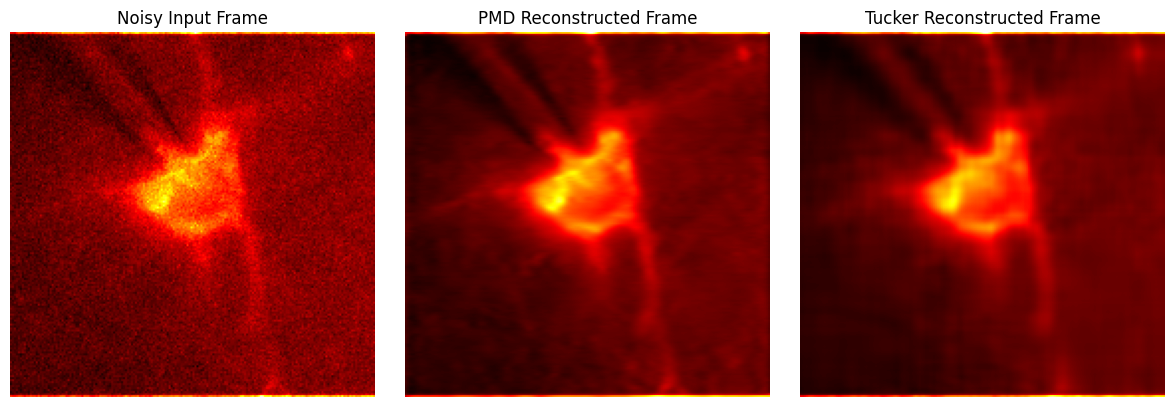

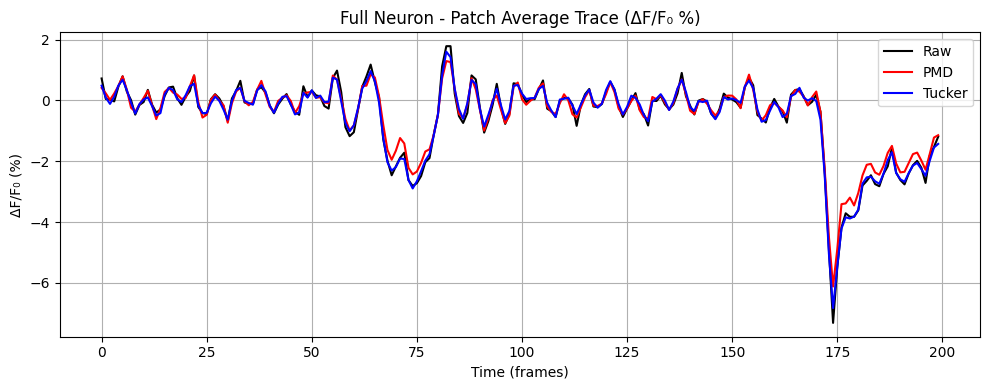

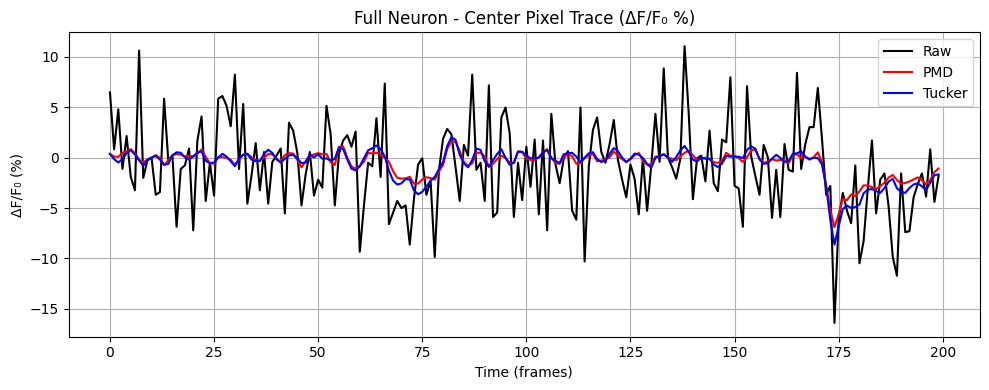

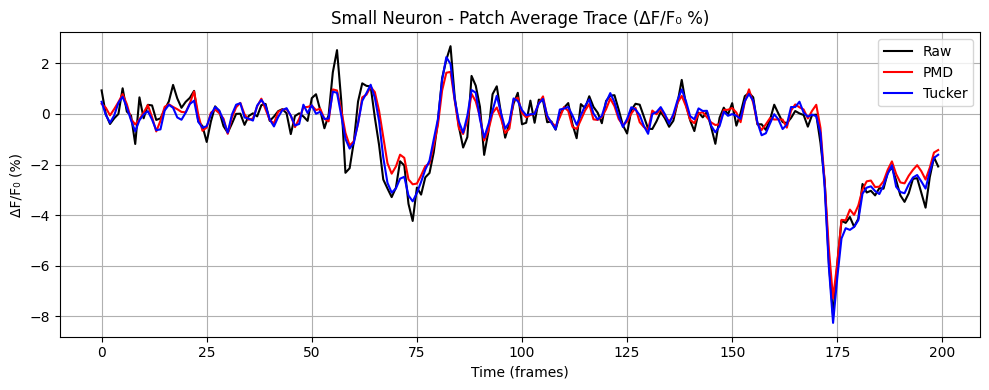

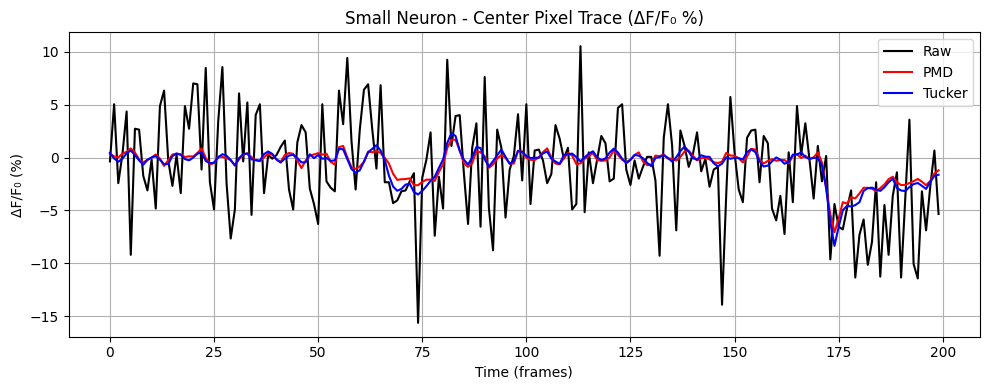

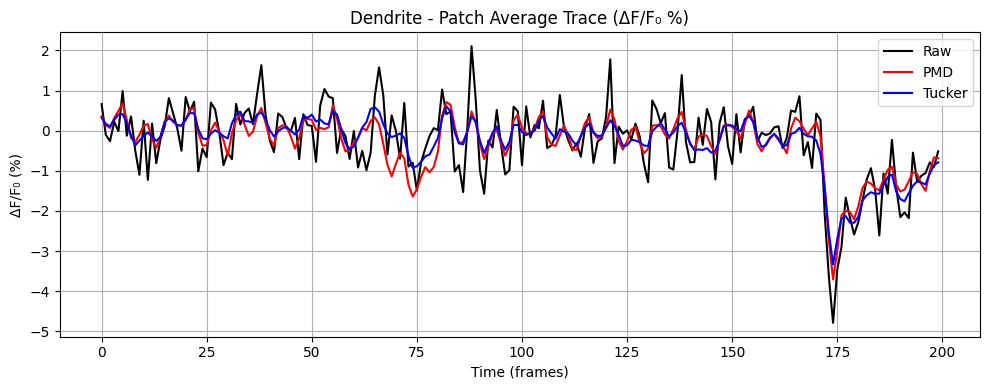

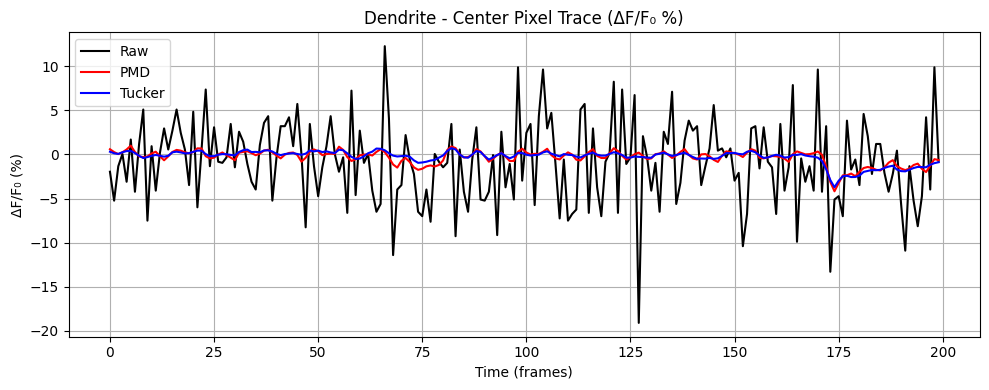

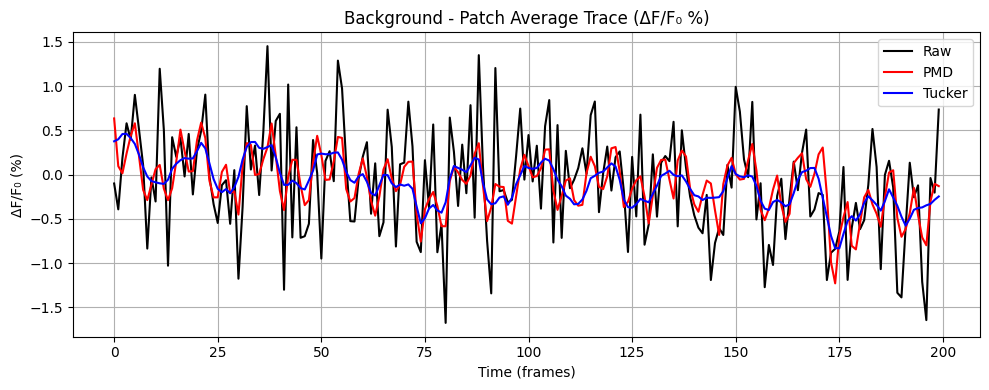

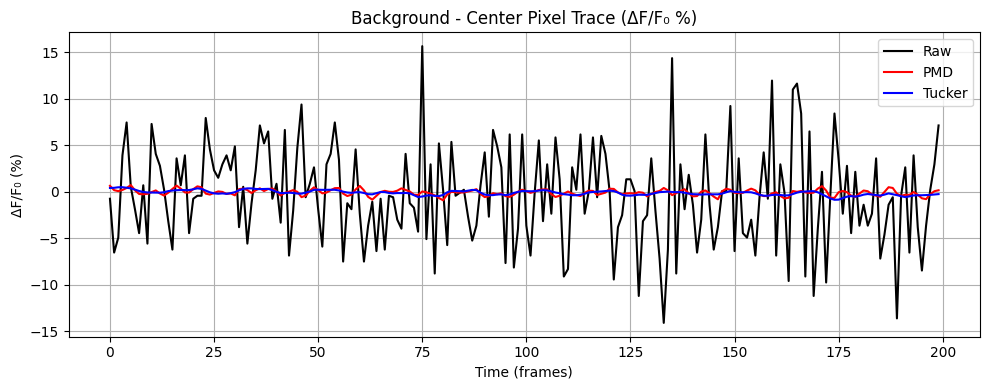

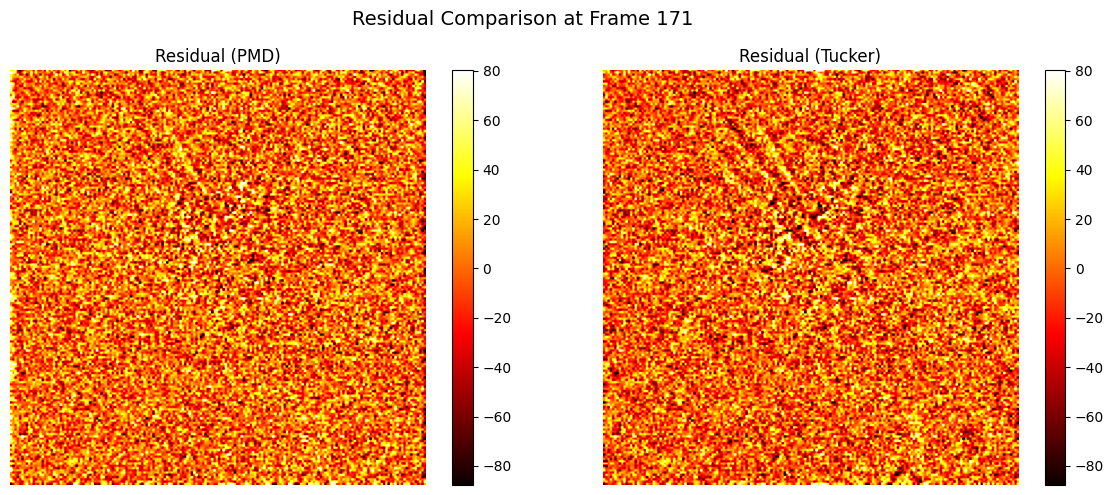


--- Full Neuron Region ---


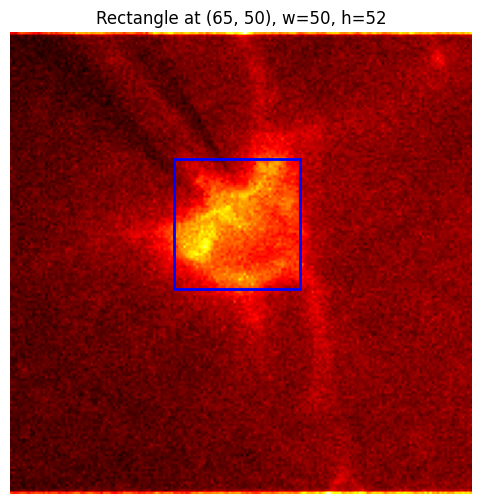


--- Small Neuron Region ---


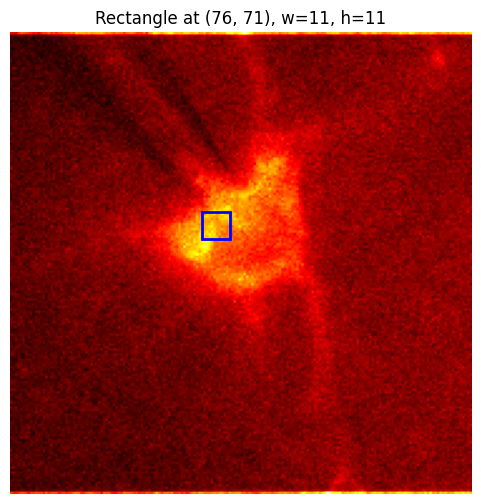


--- Dendrite Region ---


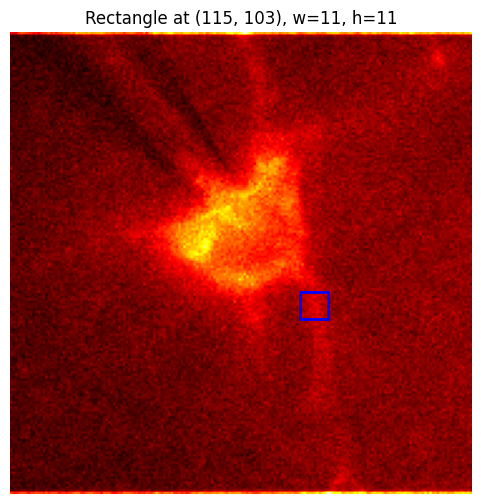


--- Background Region ---


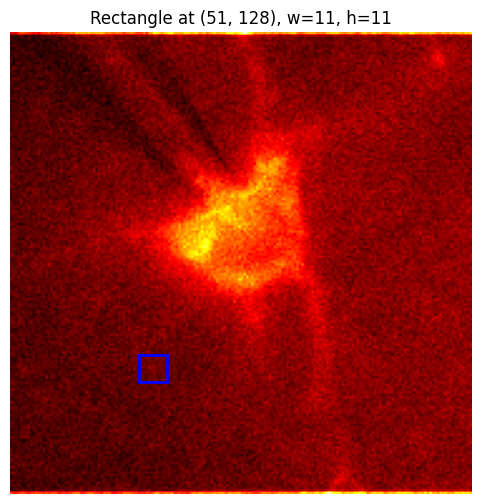

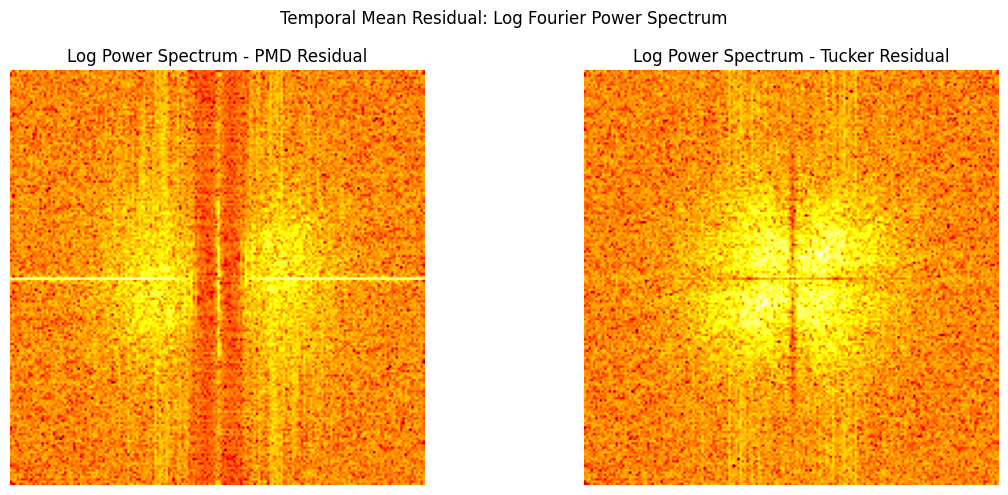

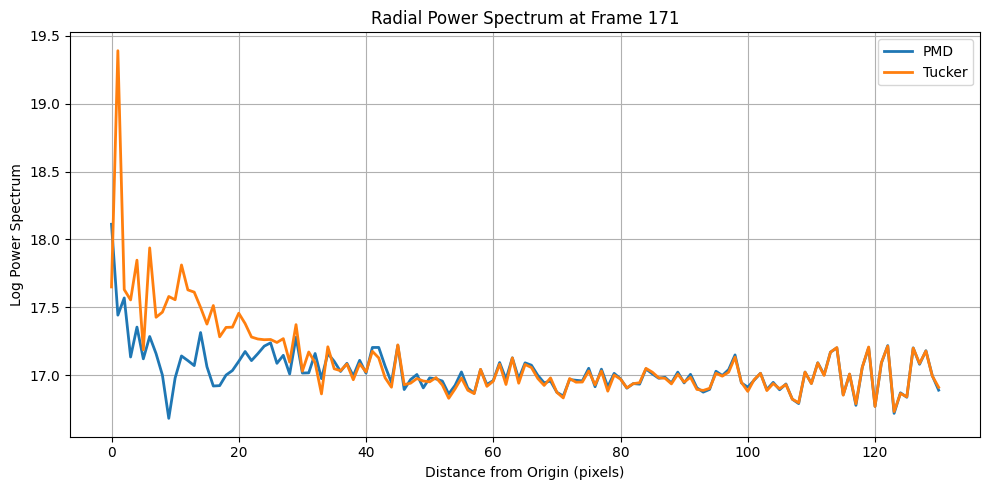


--- Full Neuron ---
Raw     | Avg Single-Pixel SNR: 4.37 dB
PMD     | Avg Single-Pixel SNR: 7.00 dB
Tucker  | Avg Single-Pixel SNR: 6.93 dB

--- Small Neuron ---
Raw     | Avg Single-Pixel SNR: 4.45 dB
PMD     | Avg Single-Pixel SNR: 7.07 dB
Tucker  | Avg Single-Pixel SNR: 7.05 dB

--- Dendrite ---
Raw     | Avg Single-Pixel SNR: 4.37 dB
PMD     | Avg Single-Pixel SNR: 6.87 dB
Tucker  | Avg Single-Pixel SNR: 6.56 dB

--- Background ---
Raw     | Avg Single-Pixel SNR: 4.26 dB
PMD     | Avg Single-Pixel SNR: 5.16 dB
Tucker  | Avg Single-Pixel SNR: 4.69 dB


In [ ]:
import os
import tifffile
import matplotlib.pyplot as plt
import numpy as np
import torch
from models.skip1d import*
from tqdm.notebook import tqdm
import time
from matplotlib.patches import Rectangle
from numpy.fft import fft2, fftshift
from scipy.stats import pearsonr

def PMD(video_tensor_flattened, rank_HW, rank_T, H, W, T, epochs, learning_rate):

    hw_inp = get_1d_posencode_inp(H*W, rank_HW//2)
    t_inp = get_1d_posencode_inp(T, rank_T//2)

    # Define parameters for skip1d
    skip_n33d = 128  # Number of channels in the downsampling path
    skip_n33u = 128  # Number of channels in the upsampling path
    skip_n11 = 4   # Number of channels in the skip connection
    num_scales = 5  # Number of scales in the skip connection
    upsample_mode = 'linear'  # Upsampling mode
    downsample_mode = 'stride'  # Downsampling mode
    pad = 'reflection'  # Padding mode
    act_fun = 'LeakyReLU'  # Activation function
    filter_size_up=3
    filter_size_down=3 
    filter_size_skip=1


    hw_net = skip1d(
        rank_HW,                       # Dimensionality of positional encoding (e.g., 32)
        rank_HW,                       # Output dimensionality = Tucker rank (e.g., 32)
        num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
        num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
        num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
        upsample_mode     = upsample_mode,
        downsample_mode   = downsample_mode,
        need_sigmoid      = False,
        need_bias         = True,
        pad               = pad,
        act_fun           = act_fun,
        filter_size_up    = filter_size_up,
        filter_size_down  = filter_size_down,
        filter_skip_size  = filter_size_skip
    )

    t_net = skip1d(
        rank_T,                       # Dimensionality of positional encoding (e.g., 32)
        rank_T,                       # Output dimensionality = Tucker rank (e.g., 32)
        num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
        num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
        num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
        upsample_mode     = upsample_mode,
        downsample_mode   = downsample_mode,
        need_sigmoid      = False,
        need_bias         = True,
        pad               = pad,
        act_fun           = act_fun,
        filter_size_up    = filter_size_up,
        filter_size_down  = filter_size_down,
        filter_skip_size  = filter_size_skip
    )

    # Switch to trairning mode
    hw_net.train()
    t_net.train()

    net_params = list(hw_net.parameters()) + list(t_net.parameters())
    inp_params = [hw_inp] + [t_inp]
    params = net_params + inp_params

    criterion_l1 = L2Norm()
        
    loss_array = np.zeros(epochs)
    mse_array = np.zeros(epochs)    
    time_array = np.zeros(epochs)

    optimizer = torch.optim.Adam(lr=learning_rate, params=params)
        
    # Create a learning scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size= epochs)

    u_inp_per = hw_inp.detach().clone()
    v_inp_per = t_inp.detach().clone()

    best_loss = float('inf')
    best_epoch = 0
    tic = time.time()

    tbar = tqdm(range(epochs))

    frame_idx = 100  # Example frame index to visualize
    x, y = 65, 50      # top-left corner (column, row)
    width, height = 50, 52

    def plot_frame_with_rectangle(frame, x, y, width, height):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(frame, cmap='hot')
        
        # Add rectangle patch
        rect = Rectangle((x, y), width, height, linewidth=2, edgecolor='b', facecolor='none')
        ax.add_patch(rect)

        ax.set_title(f"Rectangle at ({x}, {y}), w={width}, h={height}")
        plt.grid(False)
        plt.axis('off')
        plt.show()

    for idx in tbar:
        A_hw = hw_net(hw_inp).squeeze(0).permute(1, 0)  # [H, 32]
        A_t = t_net(t_inp).squeeze(0).permute(1, 0)  # [T, 32]

        recon = torch.matmul(A_hw, A_t.T)

        loss = criterion_l1(video_tensor_flattened - recon)

        # Track metrics
        loss_array[idx] = loss.item()
        time_array[idx] = time.time() - tic

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_epoch = idx
            best_reconstruction = recon.detach().clone()

        # Backprop
        optimizer.zero_grad()
        torch.autograd.set_detect_anomaly(True)
        loss.backward()
        optimizer.step()
        scheduler.step()  # optional

        # Optionally visualize or print
        if idx % 10 == 0:
            print(f'Epoch {idx:4d} | loss {loss.item():.4e}')
        
    return {
        'best_loss': best_loss,
        'best_epoch': best_epoch,
        'best_reconstruction': best_reconstruction.reshape(H, W, T).permute(2, 0, 1),
    }


def Tucker(video_tensor, rank_H, rank_W, rank_T, H, W, T, epochs, learning_rate):

    h_inp = get_1d_posencode_inp(H, rank_H//2)
    w_inp = get_1d_posencode_inp(W, rank_W//2)
    t_inp = get_1d_posencode_inp(T, rank_T//2)

    # Define parameters for skip1d
    skip_n33d = 128  # Number of channels in the downsampling path
    skip_n33u = 128  # Number of channels in the upsampling path
    skip_n11 = 4   # Number of channels in the skip connection
    num_scales = 5  # Number of scales in the skip connection
    upsample_mode = 'linear'  # Upsampling mode
    downsample_mode = 'stride'  # Downsampling mode
    pad = 'reflection'  # Padding mode
    act_fun = 'LeakyReLU'  # Activation function
    filter_size_up=3
    filter_size_down=3 
    filter_size_skip=1


    h_net = skip1d(
        rank_H,                       # Dimensionality of positional encoding (e.g., 32)
        rank_H,                       # Output dimensionality = Tucker rank (e.g., 32)
        num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
        num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
        num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
        upsample_mode     = upsample_mode,
        downsample_mode   = downsample_mode,
        need_sigmoid      = False,
        need_bias         = True,
        pad               = pad,
        act_fun           = act_fun,
        filter_size_up    = filter_size_up,
        filter_size_down  = filter_size_down,
        filter_skip_size  = filter_size_skip
    )

    w_net = skip1d(
        rank_W,                       # Dimensionality of positional encoding (e.g., 32)
        rank_W,                       # Output dimensionality = Tucker rank (e.g., 32)
        num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
        num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
        num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
        upsample_mode     = upsample_mode,
        downsample_mode   = downsample_mode,
        need_sigmoid      = False,
        need_bias         = True,
        pad               = pad,
        act_fun           = act_fun,
        filter_size_up    = filter_size_up,
        filter_size_down  = filter_size_down,
        filter_skip_size  = filter_size_skip
    )

    t_net = skip1d(
        rank_T,                       # Dimensionality of positional encoding (e.g., 32)
        rank_T,                       # Output dimensionality = Tucker rank (e.g., 32)
        num_channels_down = [skip_n33d]*num_scales if isinstance(skip_n33d, int) else skip_n33d,
        num_channels_up   = [skip_n33u]*num_scales if isinstance(skip_n33u, int) else skip_n33u,
        num_channels_skip = [skip_n11]*num_scales if isinstance(skip_n11, int) else skip_n11,
        upsample_mode     = upsample_mode,
        downsample_mode   = downsample_mode,
        need_sigmoid      = False,
        need_bias         = True,
        pad               = pad,
        act_fun           = act_fun,
        filter_size_up    = filter_size_up,
        filter_size_down  = filter_size_down,
        filter_skip_size  = filter_size_skip
    )

    # Switch to trairning mode
    h_net.train()
    w_net.train()
    t_net.train()

    net_params = list(h_net.parameters()) + list(w_net.parameters()) + list(t_net.parameters())
    inp_params = [h_inp] + [w_inp] + [t_inp]
    params = net_params + inp_params

    core = torch.nn.Parameter(torch.ones((rank_T, rank_H, rank_W), dtype=torch.float32) /
        (rank_T * rank_H * rank_W) ** 0.5)
    params += [core]

    criterion_l1 = L2Norm()
        
    loss_array = np.zeros(epochs)
    mse_array = np.zeros(epochs)    
    time_array = np.zeros(epochs)

    optimizer = torch.optim.Adam(lr=learning_rate, params=params)
        
    # Create a learning scheduler
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size= epochs)

    u_inp_per = h_inp.detach().clone()
    v_inp_per = w_inp.detach().clone()
    w_inp_per = t_inp.detach().clone()

    best_loss = float('inf')
    best_epoch = 0
    tic = time.time()

    tbar = tqdm(range(epochs))

    for idx in tbar:
        A_h = h_net(h_inp).squeeze(0).permute(1, 0)  # [H, 32]
        A_w = w_net(w_inp).squeeze(0).permute(1, 0)  # [W, 32]
        A_t = t_net(t_inp).squeeze(0).permute(1, 0)  # [T, 32]

        # recon = torch.einsum('tr,hr,wr,rxy->thw', A_t, A_h, A_w, core)  # (T,H,W)

        # 1. Multiply along temporal mode (mode-0)
        out = torch.einsum('tr, rhw -> thw', A_t, core)      # [T, R_H, R_W]

        # 2. Multiply along spatial height (mode-1)
        out = torch.einsum('trw, hr -> t w h', out, A_h)     # [T, H, R_W]

        # 3. Multiply along spatial width (mode-2)
        recon = torch.einsum('trh, wr -> thw', out, A_w)     # [T, H, W]

        loss = criterion_l1(video_tensor - recon)

        # Track metrics
        loss_array[idx] = loss.item()
        time_array[idx] = time.time() - tic

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_epoch = idx
            best_reconstruction = recon.detach().clone()

        # Backprop
        optimizer.zero_grad()
        torch.autograd.set_detect_anomaly(True)
        loss.backward()
        optimizer.step()
        scheduler.step()  # optional

        # Optionally visualize or print
        if idx % 10 == 0:
            print(f'Epoch {idx:4d} | loss {loss.item():.4e}')

    return {
        'best_loss': best_loss,
        'best_epoch': best_epoch,
        'best_reconstruction': best_reconstruction,
    }

def plot_residual(video_raw, recon_pmd, recon_tucker, frame_idx):
    residual_pmd = (recon_pmd[frame_idx] - video_raw[frame_idx]).cpu().numpy()
    residual_tucker = (recon_tucker[frame_idx] - video_raw[frame_idx]).cpu().numpy()

    # Apply slight Gaussian smoothing
    # residual_pmd_smooth = gaussian_filter(residual_pmd, sigma=1)
    # residual_tucker_smooth = gaussian_filter(residual_tucker, sigma=1)

    # Determine dynamic colormap scale from all residuals
    combined = np.concatenate([residual_pmd.ravel(), residual_tucker.ravel()])
    vmin = np.percentile(combined, 1)
    vmax = np.percentile(combined, 99)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    im1 = axs[0].imshow(residual_pmd, cmap='hot', vmin=vmin, vmax=vmax)
    axs[0].set_title('Residual (PMD)')
    axs[0].axis('off')
    fig.colorbar(im1, ax=axs[0], fraction=0.046)

    im2 = axs[1].imshow(residual_tucker, cmap='hot', vmin=vmin, vmax=vmax)
    axs[1].set_title('Residual (Tucker)')
    axs[1].axis('off')
    fig.colorbar(im2, ax=axs[1], fraction=0.046)

    plt.suptitle(f'Residual Comparison at Frame {frame_idx}', fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_frame_with_rectangle(frame, x, y, width, height):
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.imshow(frame, cmap='hot')
        
        # Add rectangle patch
        rect = Rectangle((x, y), width, height, linewidth=2, edgecolor='b', facecolor='none')
        ax.add_patch(rect)

        ax.set_title(f"Rectangle at ({x}, {y}), w={width}, h={height}")
        plt.grid(False)
        plt.axis('off')
        plt.show()

def plot_log_power_spectrum_comparison(video_scaled, recon_pmd_scaled, recon_tucker_scaled):
    def compute_log_power_spectrum(image: np.ndarray):
        f_transform = fft2(image)
        f_shifted = fftshift(f_transform)
        power_spectrum = np.abs(f_shifted) ** 2
        return np.log1p(power_spectrum)

    # Average residuals over time for visibility
    residual_pmd = torch.mean(video_scaled - recon_pmd_scaled, dim=0).cpu().numpy()
    residual_tucker = torch.mean(video_scaled - recon_tucker_scaled, dim=0).cpu().numpy()

    log_ps_pmd = compute_log_power_spectrum(residual_pmd)
    log_ps_tucker = compute_log_power_spectrum(residual_tucker)

    vmax = max(log_ps_pmd.max(), log_ps_tucker.max())
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].imshow(log_ps_pmd, cmap='hot', vmax=vmax)
    axs[0].set_title("Log Power Spectrum - PMD Residual")
    axs[0].axis('off')

    axs[1].imshow(log_ps_tucker, cmap='hot', vmax=vmax)
    axs[1].set_title("Log Power Spectrum - Tucker Residual")
    axs[1].axis('off')

    plt.suptitle("Temporal Mean Residual: Log Fourier Power Spectrum")
    plt.tight_layout()
    plt.show()

def radial_profile(data):
    """Compute radial average of a 2D array."""
    y, x = np.indices((data.shape))
    center = np.array([int(y.max() / 2), int(x.max() / 2)])
    r = np.hypot(x - center[1], y - center[0])
    r = r.astype(int)

    radial_mean = np.bincount(r.ravel(), data.ravel()) / np.bincount(r.ravel())
    return radial_mean

def plot_log_radial_power_spectrum(video_scaled, recon_pmd_scaled, recon_tucker_scaled, frame_idx):
    """Plots log of radial power spectrum for PMD and Tucker residuals at a given frame."""
    residual_pmd = (video_scaled[frame_idx] - recon_pmd_scaled[frame_idx]).cpu().numpy()
    residual_tucker = (video_scaled[frame_idx] - recon_tucker_scaled[frame_idx]).cpu().numpy()

    # Compute log power spectrum
    ps_pmd = np.abs(fftshift(fft2(residual_pmd))) ** 2
    ps_tucker = np.abs(fftshift(fft2(residual_tucker))) ** 2

    # Compute radial profile
    radial_pmd = radial_profile(np.log1p(ps_pmd))
    radial_tucker = radial_profile(np.log1p(ps_tucker))

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(radial_pmd, label="PMD", linewidth=2)
    plt.plot(radial_tucker, label="Tucker", linewidth=2)
    plt.xlabel("Distance from Origin (pixels)")
    plt.ylabel("Log Power Spectrum")
    plt.title(f"Radial Power Spectrum at Frame {frame_idx}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

def compute_snr_per_pixel(trace):
    """Compute SNR for a single pixel's time trace."""
    trace = trace - trace.mean()  # baseline correction
    sigma = trace.std()
    peak = -np.min(trace)  # assuming downward spike
    return 10 * np.log10(peak / sigma) if sigma > 0 else 0.0

def compute_avg_snr_in_patch(video_tensor, x, y, w, h):
    """
    Compute average single-pixel SNR in a patch.

    Args:
        video_tensor: shape (T, H, W)
        x, y: top-left of patch
        w, h: width, height of patch

    Returns:
        avg_snr: average SNR of all pixels in patch
    """
    patch = video_tensor[:, y:y+h, x:x+w]  # (T, h, w)
    T, h, w = patch.shape
    patch_reshaped = patch.contiguous().reshape(T, -1)  # (T, h*w)

    snrs = [compute_snr_per_pixel(patch_reshaped[:, i].cpu().numpy()) for i in range(h*w)]
    return np.mean(snrs)

def print_snr_in_categories(video_tensor_scaled, pmd_results, tucker_results):
    """
    Print average SNR for each method in specified categories.
    """
    categories = {
        'Full Neuron': (65, 50, 50, 52),
        'Small Neuron': (76, 71, 11, 11),
        'Dendrite': (115, 103, 11, 11),
        'Background': (51, 128, 11, 11),
    }

    methods = {
        "Raw": video_tensor_scaled,
        "PMD": pmd_results,
        "Tucker": tucker_results,
    }

    for region, (x, y, w, h) in categories.items():
        print(f"\n--- {region} ---")
        for label, tensor in methods.items():
            avg_snr = compute_avg_snr_in_patch(tensor, x, y, w, h)
            print(f"{label:7s} | Avg Single-Pixel SNR: {avg_snr:.2f} dB")

def extract_patch_and_center_trace(video, x, y, w, h):
    """Extract average patch trace and center pixel trace from video tensor."""
    patch = video[:, y:y+h, x:x+w]  # shape: (T, H, W)
    patch_trace = patch.mean(dim=(1, 2)).cpu().numpy()

    center_x = x + w // 2
    center_y = y + h // 2
    center_trace = video[:, center_y, center_x].cpu().numpy()

    return patch_trace, center_trace

def compute_temporal_correlation(x, y):
    """Pearson correlation between two signals"""
    return pearsonr(x, y)[0]

def compare_temporal_correlation(video_scaled, recon_pmd_scaled, recon_tucker_scaled):
    categories = {
        'Full Neuron': (65, 50, 50, 52),
        'Small Neuron': (76, 71, 11, 11),
        'Dendrite': (115, 103, 11, 11),
        'Background': (51, 128, 11, 11),
    }

    denoised_sources = {
        "PMD": recon_pmd_scaled,
        "Tucker": recon_tucker_scaled
    }

    for name, (x, y, w, h) in categories.items():
        print(f"\n--- {name} Region ---")
        raw_patch_trace, raw_center_trace = extract_patch_and_center_trace(video_scaled, x, y, w, h)
        
        for label, tensor in denoised_sources.items():
            den_patch_trace, den_center_trace = extract_patch_and_center_trace(tensor, x, y, w, h)
            
            corr_patch = compute_temporal_correlation(raw_patch_trace, den_patch_trace)
            corr_center = compute_temporal_correlation(raw_center_trace, den_center_trace)
            
            print(f"{label:7s} | Patch Corr: {corr_patch:.3f} | Center Pixel Corr: {corr_center:.3f}")

def compute_baseline_f0(trace, segments=[(0, 50), (100, 150)]): 
    baseline_vals = []
    for start, end in segments:
        baseline_vals.append(trace[start:end])
    baseline_concat = np.concatenate(baseline_vals)
    F0 = baseline_concat.mean()
    return F0
def normalize_deltaF_over_F0(trace):
    """Normalize fluorescence signal to ΔF/F₀."""
    baseline = compute_baseline_f0(trace) 
    return (trace - baseline) / baseline * 100  # percentage ΔF/F₀

def plot_time_traces(video_scaled, recon_pmd, recon_tucker):
    categories = {
        'Full Neuron': (65, 50, 50, 52),
        'Small Neuron': (76, 71, 11, 11),
        'Dendrite': (115, 103, 11, 11),
        'Background': (51, 128, 11, 11),
    }

    def extract_traces(tensor, x, y, w, h):
        patch = tensor[:, y:y+h, x:x+w]
        patch_trace = patch.mean(dim=(1, 2)).cpu().numpy()
        center_trace = tensor[:, y + h//2, x + w//2].cpu().numpy()
        return patch_trace, center_trace

    for name, (x, y, w, h) in categories.items():
        # Extract and normalize traces for raw, PMD, and Tucker
        raw_patch, raw_center = extract_traces(video_scaled, x, y, w, h)
        pmd_patch, pmd_center = extract_traces(recon_pmd, x, y, w, h)
        tucker_patch, tucker_center = extract_traces(recon_tucker, x, y, w, h)

        raw_patch_norm = normalize_deltaF_over_F0(raw_patch)
        pmd_patch_norm = normalize_deltaF_over_F0(pmd_patch)
        tucker_patch_norm = normalize_deltaF_over_F0(tucker_patch)

        raw_center_norm = normalize_deltaF_over_F0(raw_center)
        pmd_center_norm = normalize_deltaF_over_F0(pmd_center)
        tucker_center_norm = normalize_deltaF_over_F0(tucker_center)

        # --- Patch Traces ---
        plt.figure(figsize=(10, 4))
        plt.plot(raw_patch_norm, label='Raw', color='black', linewidth=1.5)
        plt.plot(pmd_patch_norm, label='PMD', color='red')
        plt.plot(tucker_patch_norm, label='Tucker', color='blue')
        plt.title(f"{name} - Patch Average Trace (ΔF/F₀ %)")
        plt.xlabel("Time (frames)")
        plt.ylabel("ΔF/F₀ (%)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # --- Center Pixel Traces ---
        plt.figure(figsize=(10, 4))
        plt.plot(raw_center_norm, label='Raw', color='black', linewidth=1.5)
        plt.plot(pmd_center_norm, label='PMD', color='red')
        plt.plot(tucker_center_norm, label='Tucker', color='blue')
        plt.title(f"{name} - Center Pixel Trace (ΔF/F₀ %)")
        plt.xlabel("Time (frames)")
        plt.ylabel("ΔF/F₀ (%)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

device = 'cpu'
torch.set_default_dtype(torch.float32)

base_path = "E:\\Voltron2_part1\\Voltron_Cell1"

tif_file = next((f for f in os.listdir(base_path) if f.endswith(".tif")), None)

tif_path = os.path.join(base_path, tif_file)

# Read TIFF file
vol_data = tifffile.imread(tif_path)  # shape: (T, H, W) or (H, W)

# Normalize the full video globally
full_video = torch.tensor(vol_data.astype(np.float32), dtype=torch.float32)
mean_val = full_video.mean()
std_val = full_video.std()

full_video_norm = (full_video - mean_val) / std_val

# Subsample 200 frames
video_tensor = full_video_norm[800:1000]

H, W, T = video_tensor.shape[1], video_tensor.shape[2], video_tensor.shape[0]

video_tensor_flattened = video_tensor.permute(1, 2, 0).reshape(-1, T)  # shape: (H*W, T)

video_tensor_scaled = video_tensor * std_val + mean_val  # Rescale to original values


rank_HW_pmd = 16
rank_T_pmd = 16
epochs_pmd = 1000
learning_rate_pmd = 1e-4

rank_H = 16
rank_W = 16
rank_T = 16
epochs = 1000
learning_rate = 1e-4

# Run PMD
pmd_results = PMD(video_tensor_flattened, rank_HW_pmd, rank_T_pmd, H, W, T, epochs_pmd, learning_rate_pmd)

# Run Tucker
tucker_results = Tucker(video_tensor, rank_H, rank_W, rank_T, H, W, T, epochs, learning_rate)

pmd_results['best_reconstruction'] = pmd_results['best_reconstruction']* std_val + mean_val
tucker_results['best_reconstruction'] = tucker_results['best_reconstruction']* std_val + mean_val

frame_idx = 171

x_full_neuron, y_full_neuron = 65, 50      # top-left corner (column, row)
width_full_neuron, height_full_neuron = 50, 52

x_small_neuron, y_small_neuron =  76, 71   # top-left corner (column, row)
width_small_neuron, height_small_neuron = 11, 11

x_dendrite, y_dendrite = 115, 103      # top-left corner (column, row)
width_dendrite, height_dendrite = 11, 11

x_background, y_background = 51, 128
width_background, height_background = 11, 11

recon_pmd_frame = pmd_results['best_reconstruction'][frame_idx].detach().cpu().numpy()
recon_tucker_frame = tucker_results['best_reconstruction'][frame_idx].detach().cpu().numpy()
gt_frame = video_tensor_scaled[frame_idx].detach().cpu().numpy()

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(gt_frame, cmap='hot')
axs[0].set_title('Noisy Input Frame')
axs[0].axis('off')

axs[1].imshow(recon_pmd_frame, cmap='hot')
axs[1].set_title('PMD Reconstructed Frame')
axs[1].axis('off')

axs[2].imshow(recon_tucker_frame, cmap='hot')
axs[2].set_title('Tucker Reconstructed Frame')
axs[2].axis('off')

plt.tight_layout()
plt.show()

plot_time_traces(video_tensor_scaled, pmd_results['best_reconstruction'], tucker_results['best_reconstruction'])

plot_residual(video_tensor_scaled, pmd_results['best_reconstruction'], tucker_results['best_reconstruction'], frame_idx)

categories = {
        'Full Neuron': (65, 50, 50, 52),
        'Small Neuron': (76, 71, 11, 11),
        'Dendrite': (115, 103, 11, 11),
        'Background': (51, 128, 11, 11),
    }

for name, (x, y, w, h) in categories.items():
    print(f"\n--- {name} Region ---")
    plot_frame_with_rectangle(video_tensor_scaled[frame_idx], x, y, w, h)

plot_log_power_spectrum_comparison(video_tensor_scaled, pmd_results['best_reconstruction'], tucker_results['best_reconstruction'])

plot_log_radial_power_spectrum(video_tensor_scaled, pmd_results['best_reconstruction'], tucker_results['best_reconstruction'], frame_idx)

print_snr_in_categories(video_tensor_scaled, pmd_results['best_reconstruction'], tucker_results['best_reconstruction'])

# compare_temporal_correlation(video_tensor_scaled, pmd_results['best_reconstruction'], tucker_results['best_reconstruction'])


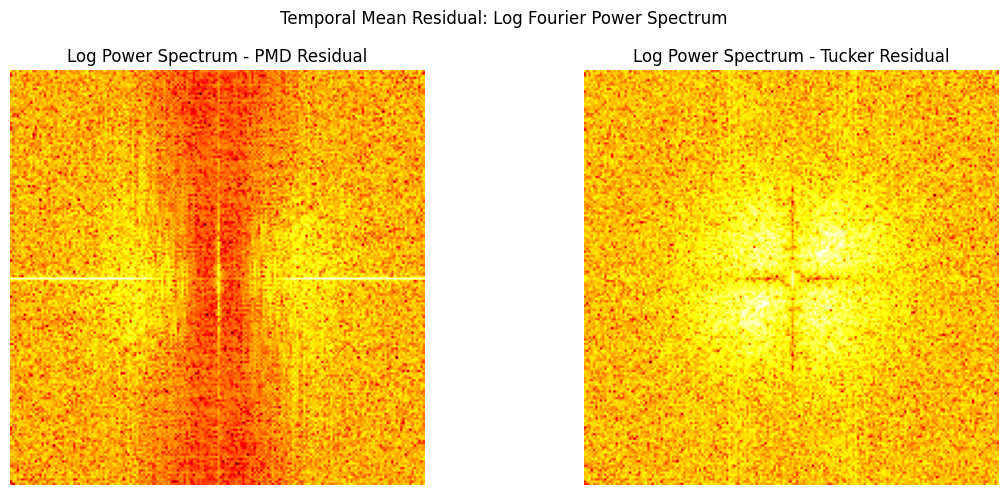

In [6]:
def plot_log_power_spectrum_comparison(video_scaled, recon_pmd_scaled, recon_tucker_scaled):
    def compute_log_power_spectrum(image: np.ndarray):
        f_transform = fft2(image)
        f_shifted = fftshift(f_transform)
        power_spectrum = np.abs(f_shifted) ** 2
        return np.log1p(power_spectrum)

    # Average residuals over time for visibility
    residual_pmd = torch.mean(video_scaled - recon_pmd_scaled, dim=0).cpu().numpy()
    residual_tucker = torch.mean(video_scaled - recon_tucker_scaled, dim=0).cpu().numpy()

    log_ps_pmd = compute_log_power_spectrum(residual_pmd)
    log_ps_tucker = compute_log_power_spectrum(residual_tucker)

    vmax = max(log_ps_pmd.max(), log_ps_tucker.max())
    
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].imshow(log_ps_pmd, cmap='hot', vmax=vmax)
    axs[0].set_title("Log Power Spectrum - PMD Residual")
    axs[0].axis('off')

    axs[1].imshow(log_ps_tucker, cmap='hot', vmax=vmax)
    axs[1].set_title("Log Power Spectrum - Tucker Residual")
    axs[1].axis('off')

    plt.suptitle("Temporal Mean Residual: Log Fourier Power Spectrum")
    plt.tight_layout()
    plt.show()

plot_log_power_spectrum_comparison(video_tensor_scaled, pmd_results['best_reconstruction'], tucker_results['best_reconstruction'])

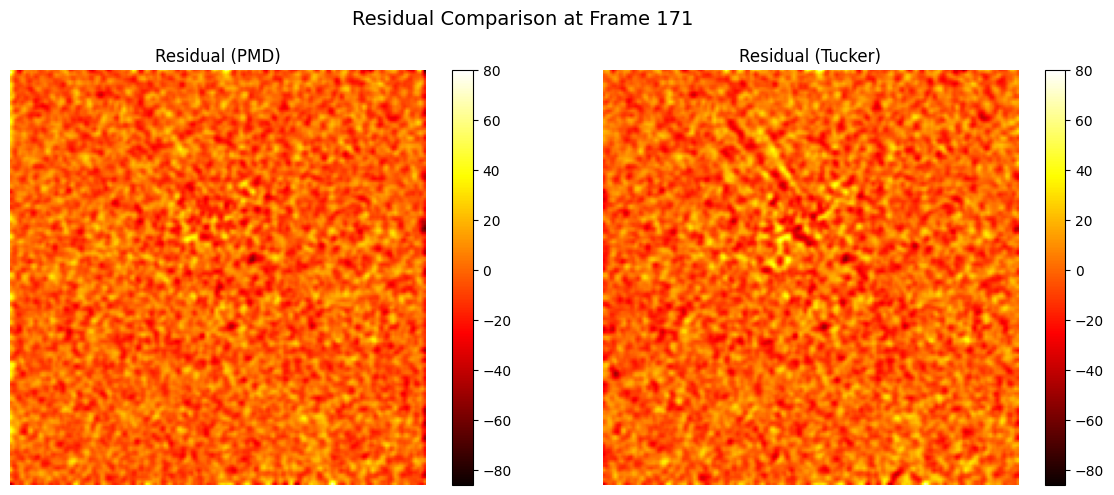

In [ ]:
from scipy.ndimage import gaussian_filter

def plot_residual_smoothed(video_raw, recon_pmd, recon_tucker, frame_idx):
    residual_pmd = (recon_pmd[frame_idx] - video_raw[frame_idx]).cpu().numpy()
    residual_tucker = (recon_tucker[frame_idx] - video_raw[frame_idx]).cpu().numpy()

    # Apply slight Gaussian smoothing
    # residual_pmd_smooth = gaussian_filter(residual_pmd, sigma=1)
    # residual_tucker_smooth = gaussian_filter(residual_tucker, sigma=1)

    # Determine dynamic colormap scale from all residuals
    combined = np.concatenate([residual_pmd.ravel(), residual_tucker.ravel()])
    vmin = np.percentile(combined, 1)
    vmax = np.percentile(combined, 99)

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    im1 = axs[0].imshow(residual_pmd, cmap='hot', vmin=vmin, vmax=vmax)
    axs[0].set_title('Residual (PMD)')
    axs[0].axis('off')
    fig.colorbar(im1, ax=axs[0], fraction=0.046)

    im2 = axs[1].imshow(residual_tucker, cmap='hot', vmin=vmin, vmax=vmax)
    axs[1].set_title('Residual (Tucker)')
    axs[1].axis('off')
    fig.colorbar(im2, ax=axs[1], fraction=0.046)

    plt.suptitle(f'Residual Comparison at Frame {frame_idx}', fontsize=14)
    plt.tight_layout()
    plt.show()

plot_residual_smoothed(video_tensor_scaled, pmd_results['best_reconstruction'], tucker_results['best_reconstruction'], frame_idx)

In [ ]:
# def compute_snr_per_pixel(trace):
#     """Compute SNR for a single pixel's time trace."""
#     trace = trace - trace.mean()  # baseline correction
#     sigma = trace.std()
#     peak = -np.min(trace)  # assuming downward spike
#     return 10 * np.log10(peak / sigma) if sigma > 0 else 0.0

# def compute_avg_snr_in_patch(video_tensor, x, y, w, h):
#     """
#     Compute average single-pixel SNR in a patch.

#     Args:
#         video_tensor: shape (T, H, W)
#         x, y: top-left of patch
#         w, h: width, height of patch

#     Returns:
#         avg_snr: average SNR of all pixels in patch
#     """
#     patch = video_tensor[:, y:y+h, x:x+w]  # (T, h, w)
#     T, h, w = patch.shape
#     patch_reshaped = patch.reshape(T, -1)  # (T, h*w)

#     snrs = [compute_snr_per_pixel(patch_reshaped[:, i].cpu().numpy()) for i in range(h*w)]
#     return np.mean(snrs)

# def print_snr_in_categories(video_tensor_scaled, pmd_results, tucker_results):
#     """
#     Print average SNR for each method in specified categories.
#     """
#     categories = {
#         'Full Neuron': (65, 50, 50, 52),
#         'Small Neuron': (76, 71, 11, 11),
#         'Dendrite': (115, 103, 11, 11),
#         'Background': (51, 128, 11, 11),
#     }

#     methods = {
#         "Raw": video_tensor_scaled,
#         "PMD": pmd_results['best_reconstruction'],
#         "Tucker": tucker_results['best_reconstruction'],
#     }

#     for region, (x, y, w, h) in categories.items():
#         print(f"\n--- {region} ---")
#         for label, tensor in methods.items():
#             avg_snr = compute_avg_snr_in_patch(tensor, x, y, w, h)
#             print(f"{label:7s} | Avg Single-Pixel SNR: {avg_snr:.2f} dB")


--- Full Neuron ---
Raw     | Avg Single-Pixel SNR: 4.37 dB
PMD     | Avg Single-Pixel SNR: 6.87 dB
Tucker  | Avg Single-Pixel SNR: 6.70 dB

--- Small Neuron ---
Raw     | Avg Single-Pixel SNR: 4.45 dB
PMD     | Avg Single-Pixel SNR: 7.03 dB
Tucker  | Avg Single-Pixel SNR: 6.62 dB

--- Dendrite ---
Raw     | Avg Single-Pixel SNR: 4.37 dB
PMD     | Avg Single-Pixel SNR: 7.02 dB
Tucker  | Avg Single-Pixel SNR: 6.78 dB

--- Background ---
Raw     | Avg Single-Pixel SNR: 4.26 dB
PMD     | Avg Single-Pixel SNR: 5.13 dB
Tucker  | Avg Single-Pixel SNR: 4.44 dB


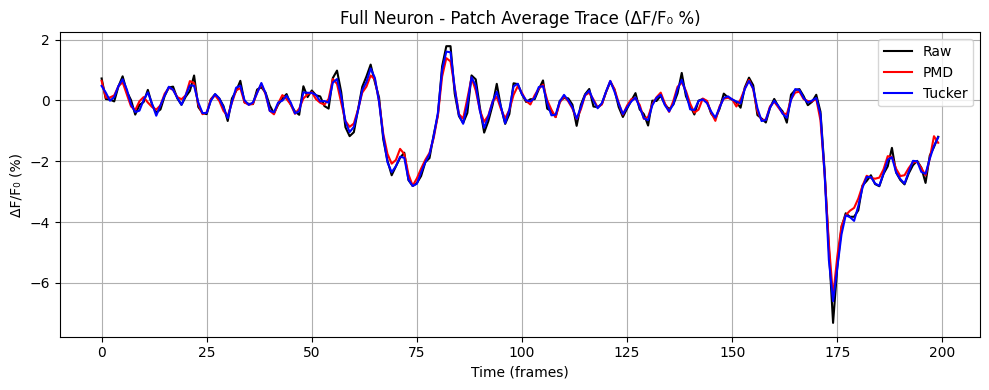

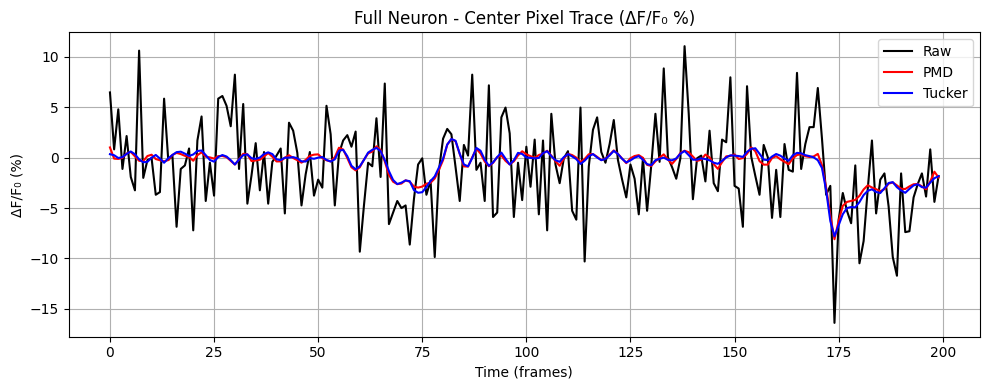

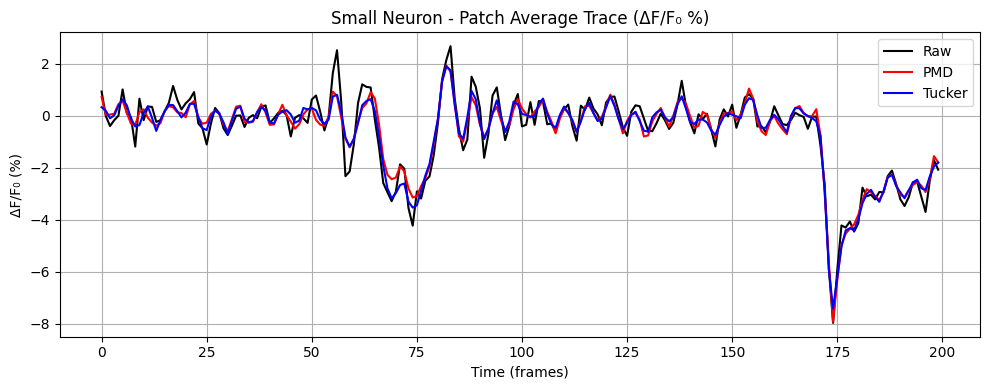

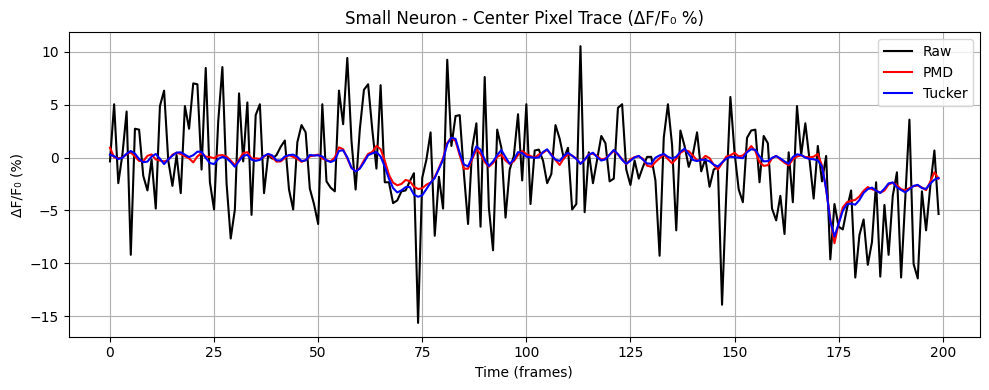

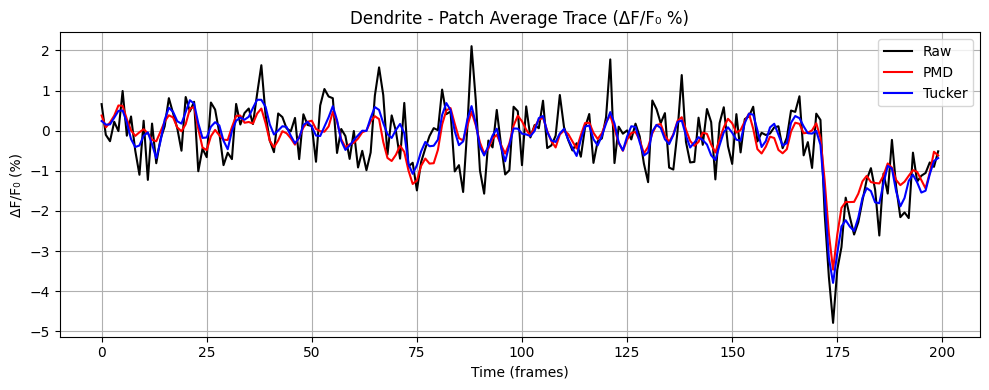

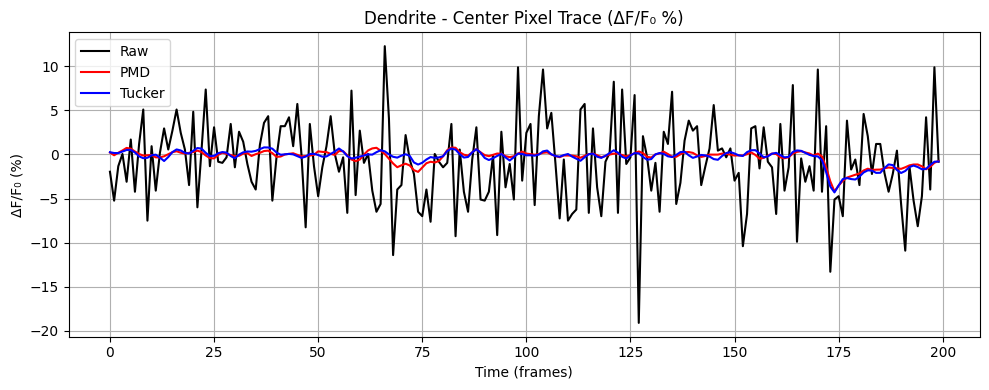

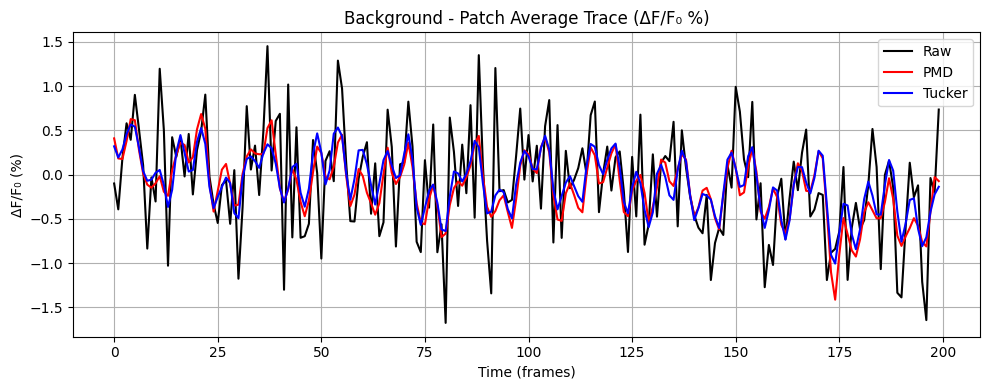

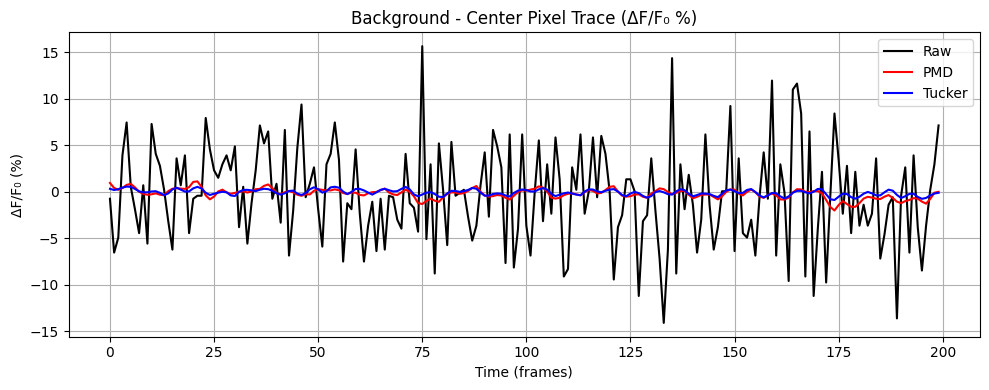

In [11]:
def compute_baseline_f0(trace, segments=[(0, 50), (100, 150)]): 
    baseline_vals = []
    for start, end in segments:
        baseline_vals.append(trace[start:end])
    baseline_concat = np.concatenate(baseline_vals)
    F0 = baseline_concat.mean()
    return F0
def normalize_deltaF_over_F0(trace):
    """Normalize fluorescence signal to ΔF/F₀."""
    baseline = compute_baseline_f0(trace) 
    return (trace - baseline) / baseline * 100  # percentage ΔF/F₀

def plot_time_traces(video_scaled, recon_pmd, recon_tucker):
    categories = {
        'Full Neuron': (65, 50, 50, 52),
        'Small Neuron': (76, 71, 11, 11),
        'Dendrite': (115, 103, 11, 11),
        'Background': (51, 128, 11, 11),
    }

    def extract_traces(tensor, x, y, w, h):
        patch = tensor[:, y:y+h, x:x+w]
        patch_trace = patch.mean(dim=(1, 2)).cpu().numpy()
        center_trace = tensor[:, y + h//2, x + w//2].cpu().numpy()
        return patch_trace, center_trace

    for name, (x, y, w, h) in categories.items():
        # Extract and normalize traces for raw, PMD, and Tucker
        raw_patch, raw_center = extract_traces(video_scaled, x, y, w, h)
        pmd_patch, pmd_center = extract_traces(recon_pmd, x, y, w, h)
        tucker_patch, tucker_center = extract_traces(recon_tucker, x, y, w, h)

        raw_patch_norm = normalize_deltaF_over_F0(raw_patch)
        pmd_patch_norm = normalize_deltaF_over_F0(pmd_patch)
        tucker_patch_norm = normalize_deltaF_over_F0(tucker_patch)

        raw_center_norm = normalize_deltaF_over_F0(raw_center)
        pmd_center_norm = normalize_deltaF_over_F0(pmd_center)
        tucker_center_norm = normalize_deltaF_over_F0(tucker_center)

        # --- Patch Traces ---
        plt.figure(figsize=(10, 4))
        plt.plot(raw_patch_norm, label='Raw', color='black', linewidth=1.5)
        plt.plot(pmd_patch_norm, label='PMD', color='red')
        plt.plot(tucker_patch_norm, label='Tucker', color='blue')
        plt.title(f"{name} - Patch Average Trace (ΔF/F₀ %)")
        plt.xlabel("Time (frames)")
        plt.ylabel("ΔF/F₀ (%)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        # --- Center Pixel Traces ---
        plt.figure(figsize=(10, 4))
        plt.plot(raw_center_norm, label='Raw', color='black', linewidth=1.5)
        plt.plot(pmd_center_norm, label='PMD', color='red')
        plt.plot(tucker_center_norm, label='Tucker', color='blue')
        plt.title(f"{name} - Center Pixel Trace (ΔF/F₀ %)")
        plt.xlabel("Time (frames)")
        plt.ylabel("ΔF/F₀ (%)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

plot_time_traces(video_tensor_scaled, pmd_results['best_reconstruction'], tucker_results['best_reconstruction'])

In [1]:
plot_log_power_spectrum_comparison(video_tensor_scaled, pmd_results['best_reconstruction'], tucker_results['best_reconstruction'])

plot_log_radial_power_spectrum(video_tensor_scaled, pmd_results['best_reconstruction'], tucker_results['best_reconstruction'], frame_idx)

print_snr_in_categories(video_tensor_scaled, pmd_results['best_reconstruction'], tucker_results['best_reconstruction'])

NameError: name 'plot_log_power_spectrum_comparison' is not defined